In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


### Load Covid-19 Datasets

In [2]:
df=pd.read_csv('Covid-19_data.csv')

In [3]:
df

,Date,Country,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,WHO Region
0,22-01-2020,Afghanistan,0,0,0,0,0,0,0,Eastern Mediterranean
1,22-01-2020,Albania,0,0,0,0,0,0,0,Europe
2,22-01-2020,Algeria,0,0,0,0,0,0,0,Africa
3,22-01-2020,Andorra,0,0,0,0,0,0,0,Europe
4,22-01-2020,Angola,0,0,0,0,0,0,0,Africa
...,...,...,...,...,...,...,...,...,...,...
35151,27-07-2020,West Bank and Gaza,10621,78,3752,6791,152,2,0,Eastern Mediterranean
35152,27-07-2020,Western Sahara,10,1,8,1,0,0,0,Africa
35153,27-07-2020,Yemen,1691,483,833,375,10,4,36,Eastern Mediterranean
35154,27-07-2020,Zambia,4552,140,2815,1597,71,1,465,Africa


## Country wise Daily/Weekly Cases 

### First Take Zimbabwe

In [4]:
Z=df[df['Country']=='Zimbabwe']

In [5]:
Z

,Date,Country,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,WHO Region
186,22-01-2020,Zimbabwe,0,0,0,0,0,0,0,Africa
373,23-01-2020,Zimbabwe,0,0,0,0,0,0,0,Africa
560,24-01-2020,Zimbabwe,0,0,0,0,0,0,0,Africa
747,25-01-2020,Zimbabwe,0,0,0,0,0,0,0,Africa
934,26-01-2020,Zimbabwe,0,0,0,0,0,0,0,Africa
...,...,...,...,...,...,...,...,...,...,...
34407,23-07-2020,Zimbabwe,2124,28,510,1586,90,2,0,Africa
34594,24-07-2020,Zimbabwe,2296,32,514,1750,172,4,4,Africa
34781,25-07-2020,Zimbabwe,2434,34,518,1882,138,2,4,Africa
34968,26-07-2020,Zimbabwe,2512,34,518,1960,78,0,0,Africa


In [6]:

Z =Z.set_index('Date')
Z= Z.sort_values('Date')

In [7]:
Z

,Country,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,WHO Region
Date,,,,,,,,,
01-02-2020,Zimbabwe,0,0,0,0,0,0,0,Africa
01-03-2020,Zimbabwe,0,0,0,0,0,0,0,Africa
01-04-2020,Zimbabwe,8,1,0,7,0,0,0,Africa
01-05-2020,Zimbabwe,40,4,5,31,0,0,0,Africa
01-06-2020,Zimbabwe,203,4,29,170,25,0,0,Africa
...,...,...,...,...,...,...,...,...,...
30-05-2020,Zimbabwe,174,4,29,141,25,0,1,Africa
30-06-2020,Zimbabwe,591,7,162,422,17,0,10,Africa
31-01-2020,Zimbabwe,0,0,0,0,0,0,0,Africa


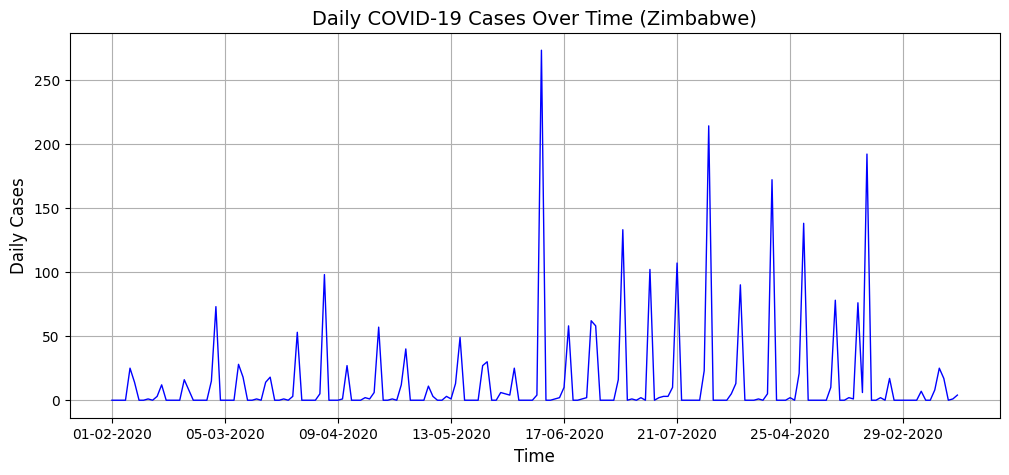

In [8]:
Daily_case = Z['New cases']

plt.figure(figsize=(12,5))

Daily_case.plot(color='blue', linewidth=1)

plt.title("Daily COVID-19 Cases Over Time (Zimbabwe)", fontsize=14)
plt.xlabel("Time", fontsize=12)
plt.ylabel("Daily Cases", fontsize=12)

plt.grid(True)
plt.show()

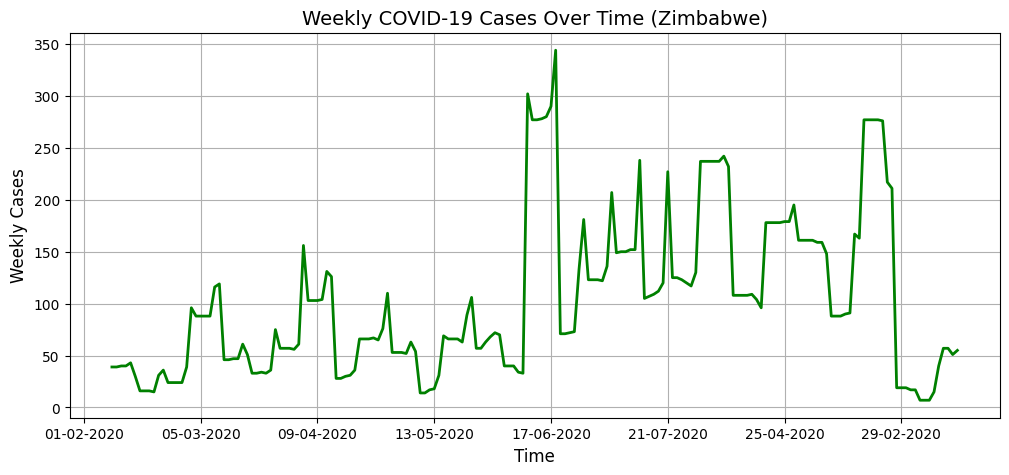

In [9]:
# Compute Weekly Cases (7-day sum)
Z['Weekly_cases'] = Z['New cases'].rolling(7).sum()

Weekly_case = Z['Weekly_cases']

plt.figure(figsize=(12,5))

Weekly_case.plot(color='green', linewidth=2)

plt.title("Weekly COVID-19 Cases Over Time (Zimbabwe)", fontsize=14)
plt.xlabel("Time", fontsize=12)
plt.ylabel("Weekly Cases", fontsize=12)

plt.grid(True)
plt.show()

C:\Users\manda\AppData\Local\Temp\ipykernel_22420\1172420292.py:6: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  data['Date'] = pd.to_datetime(data['Date'])
C:\Users\manda\AppData\Local\Temp\ipykernel_22420\1172420292.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Date'] = pd.to_datetime(data['Date'])


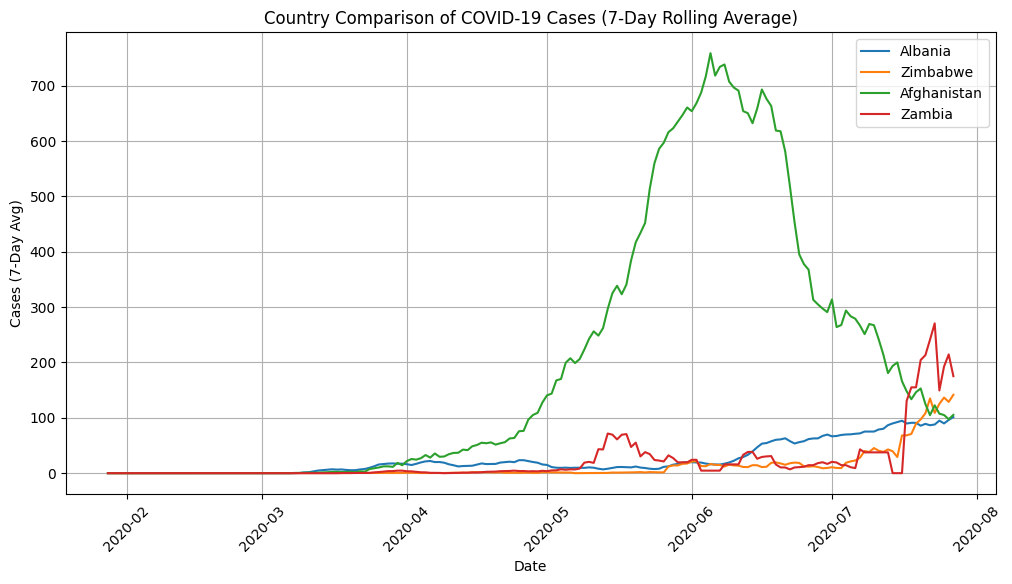

In [10]:
# Select countries
countries = ['Albania','Zimbabwe','Afghanistan','Zambia']
data = df[df['Country'].isin(countries)]

# Convert date and sort
data['Date'] = pd.to_datetime(data['Date'])
data = data.sort_values(['Country','Date'])

# Compute 7-day rolling average of daily cases
data['Rolling_avg'] = data.groupby('Country')['New cases'].transform(lambda x: x.rolling(7).mean())

# Plot comparison
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for c in countries:
    subset = data[data['Country'] == c]
    plt.plot(subset['Date'], subset['Rolling_avg'], label=c)

plt.title("Country Comparison of COVID-19 Cases (7-Day Rolling Average)")
plt.xlabel("Date")
plt.ylabel("Cases (7-Day Avg)")

plt.legend()
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [11]:
countries = ['Albania','Zimbabwe','Afghanistan','Zambia']
data = df[df['Country'].isin(countries)]

# Convert date
data['Date'] = pd.to_datetime(data['Date'])

# Find peak daily cases for each country
peaks = data.groupby('Country')['New cases'].max()

print("Peak Daily Cases:")
print(peaks)

Peak Daily Cases:
Country
Afghanistan    915
Albania        126
Zambia         915
Zimbabwe       273
Name: New cases, dtype: int64


C:\Users\manda\AppData\Local\Temp\ipykernel_22420\3795537099.py:5: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  data['Date'] = pd.to_datetime(data['Date'])
C:\Users\manda\AppData\Local\Temp\ipykernel_22420\3795537099.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Date'] = pd.to_datetime(data['Date'])


### Peak Case

In [12]:
peak_dates = data.loc[data.groupby('Country')['New cases'].idxmax(), ['Country','Date','New cases']]

print(peak_dates)

           Country       Date  New cases
25245  Afghanistan 2020-06-05        915
34783      Albania 2020-07-26        126
33284       Zambia 2020-07-17        915
33098     Zimbabwe 2020-07-16        273


##  Summary

### Each country experienced a different peak infection date.

### Afghanistan recorded the highest peak among the selected countries.

### Albania showed a comparatively smaller peak.

### The peaks indicate the period when COVID-19 spread most rapidly in each country.

### Such comparisons help understand differences in outbreak intensity across regions.

In [13]:
data['Growth_rate'] = data.groupby('Country')['New cases'].pct_change()

reproduction_insight = data.groupby('Country')['Growth_rate'].mean()

print("Average Growth Rate (Reproduction Insight):")
print(reproduction_insight)

Average Growth Rate (Reproduction Insight):
Country
Afghanistan    inf
Albania        inf
Zambia         inf
Zimbabwe       inf
Name: Growth_rate, dtype: float64


C:\Users\manda\AppData\Local\Temp\ipykernel_22420\2698613325.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Growth_rate'] = data.groupby('Country')['New cases'].pct_change()


## Conclusions

### The time series analysis shows that COVID-19 cases varied significantly over time across different countries.

### Daily case data contains high fluctuations, but applying a 7-day rolling average helps smooth the noise and reveal clear trends.

### Peak detection indicates the periods when infection spread was highest in each country.

### Country comparison suggests that outbreak intensity and timing differed across regions.

### Such analysis helps understand pandemic dynamics and supports better monitoring of disease spread.